In [22]:
import pandas as pd
df = pd.read_csv('Subject 1.csv', parse_dates=['EventDateTime'])
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11042 entries, 0 to 11041
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   EventDateTime               11042 non-null  datetime64[ns]
 1   DeviceMode                  0 non-null      float64       
 2   BolusType                   593 non-null    object        
 3   Basal                       7419 non-null   float64       
 4   CorrectionDelivered         593 non-null    float64       
 5   TotalBolusInsulinDelivered  593 non-null    float64       
 6   FoodDelivered               593 non-null    float64       
 7   CarbSize                    593 non-null    float64       
 8   CGM                         11042 non-null  int64         
dtypes: datetime64[ns](1), float64(6), int64(1), object(1)
memory usage: 776.5+ KB


In [23]:
df = df.sort_values('EventDateTime')

In [24]:
df['EventDateTime'] = pd.to_datetime(df['EventDateTime'])
df = df.set_index('EventDateTime')

In [25]:
df['hour'] = df.index.hour
df['day_of_week'] = df.index.dayofweek
df['day_night'] = df['hour'].apply(lambda x: 0 if (x < 6 or x >= 20) else 1)


In [26]:
import numpy as np

df['hour_sin'] = np.sin(2 * np.pi * df['hour']/24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour']/24)

df['day_of_week_sin'] = np.sin(2 * np.pi * df['day_of_week']/7)
df['day_of_week_cos'] = np.cos(2 * np.pi * df['day_of_week']/7)



In [27]:
df['FoodDelivered'].fillna(0, inplace=True)
df['TotalBolusInsulinDelivered'].fillna(0,inplace=True)
df = df.drop(columns=['DeviceMode'])
df['BolusType'] = df['BolusType'].fillna('NoBolus')
df = pd.get_dummies(df, columns=['BolusType'], prefix='Bolus')
df['ActiveBolus'] = df['TotalBolusInsulinDelivered'].rolling(window=24, min_periods=1).sum()

/var/folders/8r/w2tfcf3d63b2dfp05x4fmyx40000gn/T/ipykernel_2591/2650873872.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['FoodDelivered'].fillna(0, inplace=True)
/var/folders/8r/w2tfcf3d63b2dfp05x4fmyx40000gn/T/ipykernel_2591/2650873872.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always beha

In [28]:
df['FoodDelivered'].fillna(0, inplace=True)
df['CarbSize'].fillna(0, inplace=True)
df['TotalBolusInsulinDelivered'].fillna(0, inplace=True)
df['Basal'].fillna(method='ffill', inplace=True)  
df['CorrectionDelivered'].fillna(0, inplace=True) 
df['Basal'].fillna(df['Basal'].mean(), inplace=True)


/var/folders/8r/w2tfcf3d63b2dfp05x4fmyx40000gn/T/ipykernel_2591/1495881271.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['FoodDelivered'].fillna(0, inplace=True)
/var/folders/8r/w2tfcf3d63b2dfp05x4fmyx40000gn/T/ipykernel_2591/1495881271.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always beha

In [29]:
features = [
    'hour_sin', 'hour_cos',
    'day_of_week_sin', 'day_of_week_cos',
    'day_night',
    'FoodDelivered', 'CarbSize',
    'TotalBolusInsulinDelivered', 'Basal', 'CorrectionDelivered',
    'ActiveBolus', 'Bolus_Automatic Bolus/Correction', 'Bolus_BLE Standard Bolus/Correction', 'Bolus_Extended 50.00%/0.00',
    'Bolus_Standard', 'Bolus_Standard/Correction', 'Bolus_NoBolus'
]

target = 'CGM'

In [30]:
import os
import random
import numpy as np
import tensorflow as tf

SEED = 42

os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [31]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout, Conv1D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import Huber
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd

df['delta_CGM'] = df['CGM'].diff().fillna(0)  
df['CGM_roll_3'] = df['CGM'].rolling(window=3, min_periods=1).mean()  

df['CGM_lag_5'] = df['CGM'].shift(1).fillna(method='bfill')
df['CGM_lag_10'] = df['CGM'].shift(2).fillna(method='bfill')
df['CGM_lag_15'] = df['CGM'].shift(3).fillna(method='bfill')
df['delta_CGM_2'] = df['CGM'].diff(2).fillna(0)

features_with_delta = features + ['delta_CGM', 'CGM_roll_3', 'CGM_lag_5', 'CGM_lag_10', 'CGM_lag_15', 'delta_CGM_2']
target = 'CGM'

scaler_X = MinMaxScaler()
df[features_with_delta] = scaler_X.fit_transform(df[features_with_delta])

scaler_y = MinMaxScaler()
y_scaled = scaler_y.fit_transform(df[target].values.reshape(-1,1))

window_size = 12  
X, y = [], []

for i in range(len(df) - window_size):
    X.append(df[features_with_delta].iloc[i:i+window_size].values)
    y.append(y_scaled[i+window_size]) 

X = np.array(X)
y = np.array(y)

split = int(len(X) * 0.8)
X_train, X_val = X[:split], X[split:]
y_train, y_val = y[:split], y[split:]

model = Sequential()
model.add(Conv1D(filters=16, kernel_size=3, activation='relu',
                 input_shape=(X.shape[1], X.shape[2])))

model.add(GRU(32,
              return_sequences=True,
              dropout=0.2,
              kernel_regularizer=l2(0.0005)))

model.add(GRU(16,
              dropout=0.2,
              kernel_regularizer=l2(0.0005)))

model.add(Dense(8, activation='relu'))
model.add(Dense(1))

optimizer = Adam(learning_rate=0.0003)
model.compile(optimizer=optimizer, loss=Huber(delta=1.0))  

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)
checkpoint = ModelCheckpoint(
    'best_model.h5', monitor='val_loss', save_best_only=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=60,
    batch_size=16,
    callbacks=[early_stop, checkpoint]
)

y_pred_scaled = model.predict(X_val)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = scaler_y.inverse_transform(y_val)

/var/folders/8r/w2tfcf3d63b2dfp05x4fmyx40000gn/T/ipykernel_2591/3059791259.py:18: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['CGM_lag_5'] = df['CGM'].shift(1).fillna(method='bfill')
/var/folders/8r/w2tfcf3d63b2dfp05x4fmyx40000gn/T/ipykernel_2591/3059791259.py:19: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['CGM_lag_10'] = df['CGM'].shift(2).fillna(method='bfill')
/var/folders/8r/w2tfcf3d63b2dfp05x4fmyx40000gn/T/ipykernel_2591/3059791259.py:20: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['CGM_lag_15'] = df['CGM'].shift(3).fillna(method='bfill')
/Users/user/anaconda3/envs/my_cozy_env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_d

Epoch 1/60
552/552 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0465

552/552 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 0.0318 - val_loss: 0.0140
Epoch 2/60
548/552 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0147

552/552 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0127 - val_loss: 0.0082
Epoch 3/60
551/552 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0092

552/552 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0085 - val_loss: 0.0059
Epoch 4/60
550/552 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0068

...

552/552 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0012 - val_loss: 6.0506e-04
Epoch 28/60
551/552 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0013

552/552 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0012 - val_loss: 5.9391e-04
Epoch 29/60
550/552 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0012

552/552 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0011 - val_loss: 5.9128e-04
Epoch 30/60
549/552 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0012

552/552 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.0012 - val_loss: 5.6832e-04
Epoch 31/60
552/552 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0011 - val_loss: 6.2310e-04
Epoch 32/60
552/552 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.0011 - val_loss: 5.7444e-04
Epoch 33/60
552/552 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.0011 - val_loss: 6.2038e-04
Epoch 34/60
552/552 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.0010 - val_loss: 6.7513e-04
Epoch 35/60
548/552 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0011

552/552 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.0011 - val_loss: 5.5240e-04
Epoch 36/60
552/552 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0010 - val_loss: 6.0923e-04
Epoch 37/60
552/552 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0011 - val_loss: 5.7864e-04
Epoch 38/60
552/552 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 9.7753e-04 - val_loss: 6.4768e-04
Epoch 39/60
552/552 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0010 - val_loss: 5.8808e-04
Epoch 40/60
552/552 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 9.9481e-04 - val_loss: 5.8695e-04
Epoch 41/60
552/552 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0010 - val_loss: 6.5108e-04
Epoch 42/60
552/552 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 9.1491e-04 - val_loss: 7.1321e-04
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


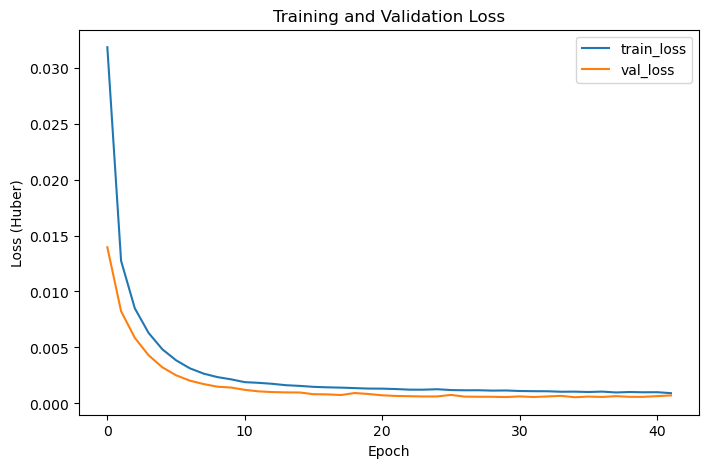

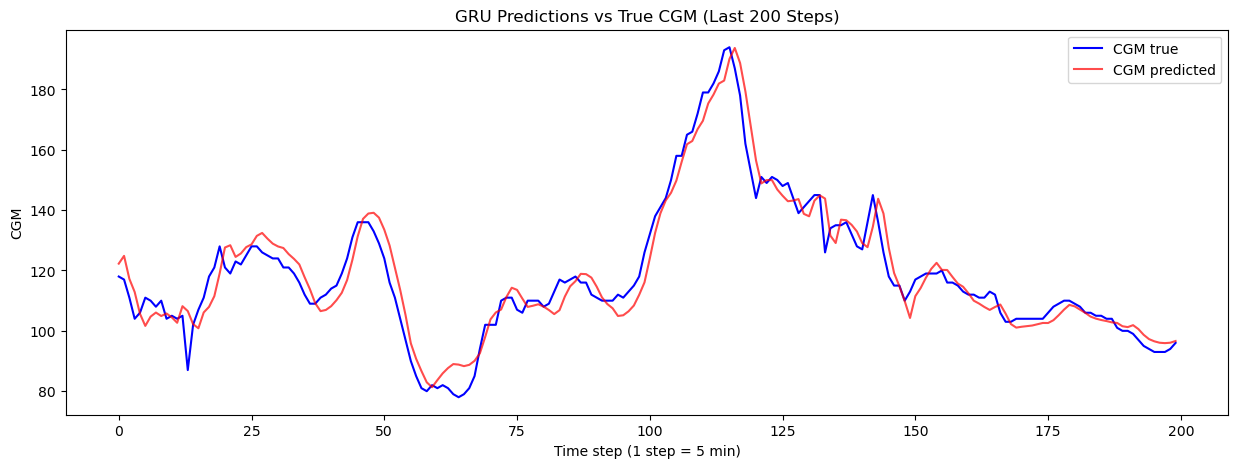

In [32]:
figures_dir = '/Users/user/Documents/projects/Glucose Forecasting and Insulin Dynamics Analysis in Type 1 Diabetes/Glucose-Forecasting-and-Insulin-Dynamics-Analysis-in-Type-1-Diabetes/figures'

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (Huber)')
plt.legend()
plt.title('Training and Validation Loss')
plt.savefig(os.path.join(figures_dir, 'loss_curve.png'), dpi=300, bbox_inches='tight')
plt.show()

n_steps = 200
plt.figure(figsize=(15,5))
plt.plot(y_true[-n_steps:], label='CGM true', color='blue')
plt.plot(y_pred[-n_steps:], label='CGM predicted', color='red', alpha=0.7)
plt.xlabel('Time step (1 step = 5 min)')
plt.ylabel('CGM')
plt.title('GRU Predictions vs True CGM (Last 200 Steps)')
plt.legend()
plt.savefig(os.path.join(figures_dir, 'cgm_predictions_last200.png'), dpi=300, bbox_inches='tight')
plt.show()

In [33]:
errors = pd.DataFrame({
    'time_step': np.arange(len(y_true)),
    'CGM_true': y_true.flatten(),
    'CGM_pred': y_pred.flatten()
})
errors['abs_error'] = np.abs(errors['CGM_true'] - errors['CGM_pred'])
errors['percent_error'] = errors['abs_error'] / errors['CGM_true'] * 100

top_errors = errors.nlargest(10, 'abs_error')
print(top_errors)

      time_step  CGM_true    CGM_pred  abs_error  percent_error
273         273     214.0  144.460129  69.539871      32.495267
1165       1165     279.0  244.171570  34.828430      12.483308
1164       1164     261.0  227.273834  33.726166      12.921903
232         232     138.0  107.401123  30.598877      22.173099
1807       1807     158.0  188.027008  30.027008      19.004435
242         242     105.0  134.106537  29.106537      27.720511
428         428     136.0  110.746002  25.253998      18.569116
227         227     109.0  134.194687  25.194687      23.114392
35           35     105.0  129.321533  24.321533      23.163365
1716       1716      84.0  108.271065  24.271065      28.894125


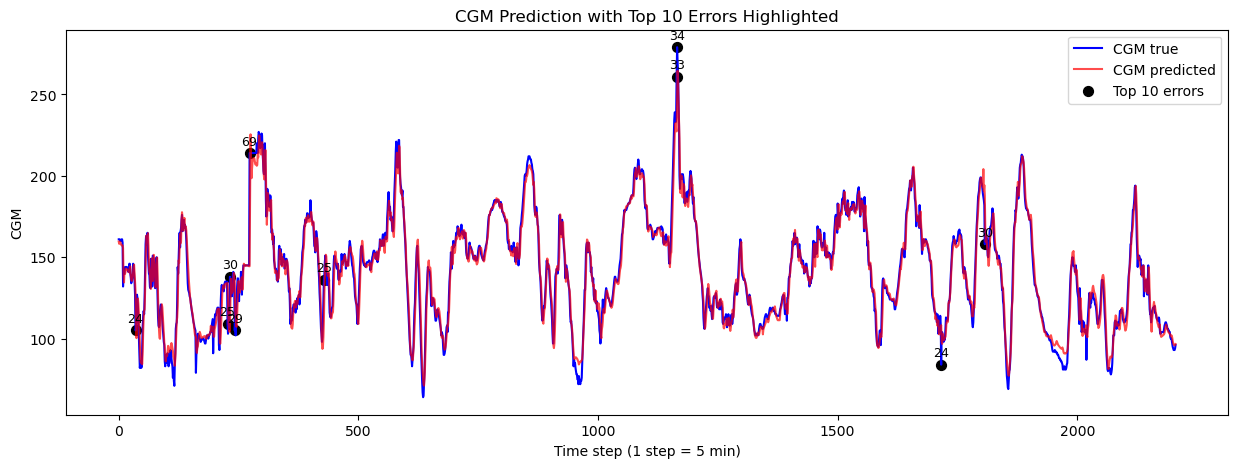

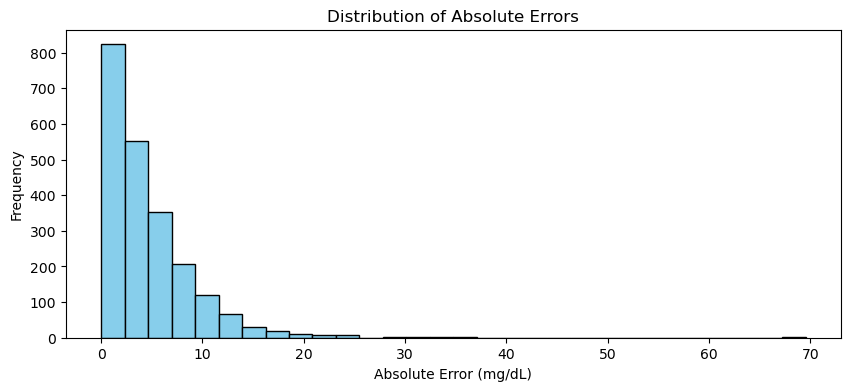

In [34]:
plt.figure(figsize=(15,5))
plt.plot(y_true, label='CGM true', color='blue')
plt.plot(y_pred, label='CGM predicted', color='red', alpha=0.7)
plt.scatter(top_errors['time_step'], top_errors['CGM_true'], color='black', label='Top 10 errors', s=50)

for i, row in top_errors.iterrows():
    plt.text(row['time_step'], row['CGM_true'] + 5, f"{int(row['abs_error'])}", 
             color='black', fontsize=9, ha='center')

plt.xlabel('Time step (1 step = 5 min)')
plt.ylabel('CGM')
plt.title('CGM Prediction with Top 10 Errors Highlighted')
plt.legend()
plt.savefig(os.path.join(figures_dir, 'cgm_top10_errors.png'), dpi=300, bbox_inches='tight')
plt.show()


plt.figure(figsize=(10,4))
plt.hist(errors['abs_error'], bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Absolute Error (mg/dL)')
plt.ylabel('Frequency')
plt.title('Distribution of Absolute Errors')
plt.savefig(os.path.join(figures_dir, 'abs_error_distribution.png'), dpi=300, bbox_inches='tight')
plt.show()

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


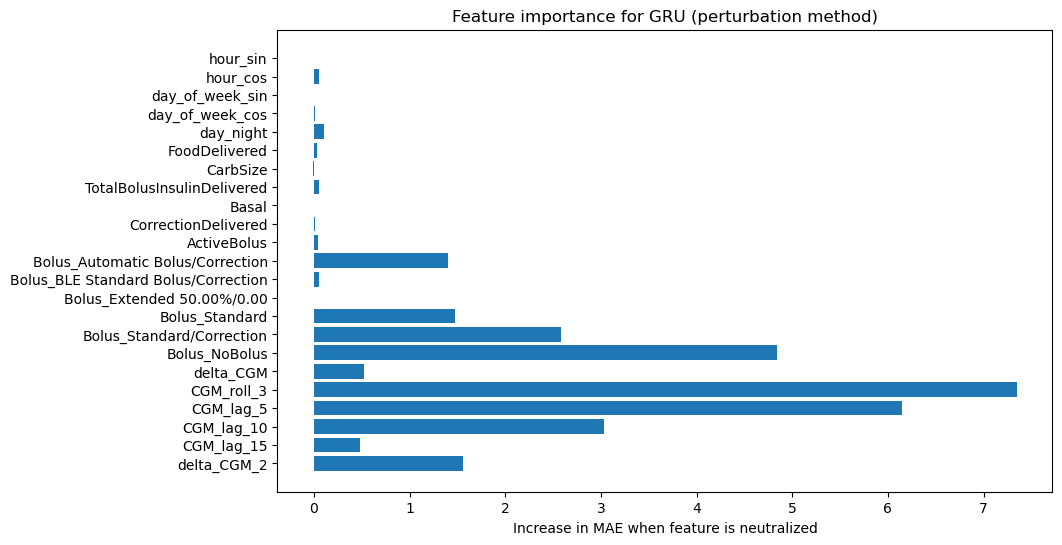

In [35]:
from sklearn.metrics import mean_absolute_error


y_pred_orig = scaler_y.inverse_transform(model.predict(X_val))
baseline_mae = mean_absolute_error(y_true, y_pred_orig)

feature_importance = []

for i, feat in enumerate(features_with_delta):
    X_perturbed = X_val.copy()
    X_perturbed[:,:,i] = np.mean(X_val[:,:,i])
    y_pred_pert = scaler_y.inverse_transform(model.predict(X_perturbed))
    pert_mae = mean_absolute_error(y_true, y_pred_pert)
    feature_importance.append(pert_mae - baseline_mae)

plt.figure(figsize=(10,6))
plt.barh(features_with_delta, feature_importance)
plt.xlabel('Increase in MAE when feature is neutralized')
plt.title('Feature importance for GRU (perturbation method)')
plt.gca().invert_yaxis()
plt.savefig(os.path.join(figures_dir, 'feature_importance.png'), dpi=300, bbox_inches='tight')
plt.show()

In [36]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print(f"MAE: {mae:.2f} mg/dL")
print(f"RMSE: {rmse:.2f} mg/dL")
print(f"MAPE: {mape:.2f}%")

MAE: 4.59 mg/dL
RMSE: 6.45 mg/dL
MAPE: 3.47%
